In [ ]:
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import numpy as np

# SIRT-C Model with Two Infected Compartments

S = Suceptible

I_L = Low Pain

I_H = High Pain

T = Treatment

R = Recovered

C = Chronic Pain

Text(0.5, 1.0, 'SIIRT-C')

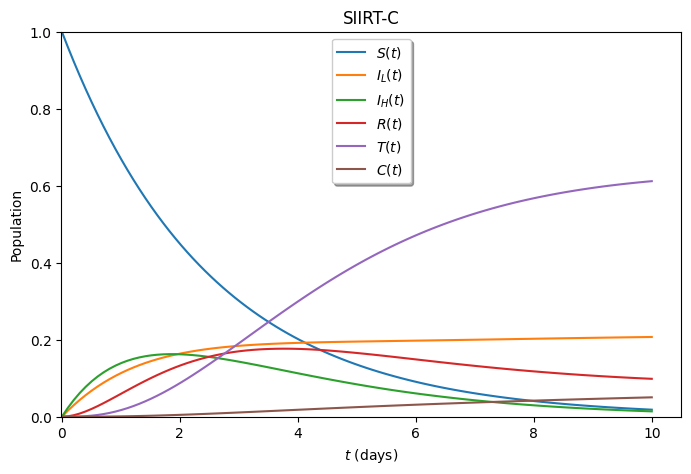

In [ ]:
t_initial, t_final = 0, 10
S0, I_L0, I_H0, T0, R0, C0 = 1, 0, 0, 0.00, 0.00, 0.00

alpha = 0.4 # infection rate
lamba = 0.8 # rate of moving out of recovery
p = 0.95 # probability of recovery
rho = 0.1 # relapse rate into low pain
q = 0.4 # probability of pain being low pain
tau_L = 0.3 # treatment rate for low pain
tau_H = 0.7 # treatment rate for high pain

Y0 = [S0, I_L0, I_H0, T0, R0, C0]
t_span = (t_initial , t_final)


def sir(t, y, alpha, lamba, p, rho, q, tau_L, tau_H):
  S, I_L, I_H, T, R, C = y
  return [
    -alpha * S,
    q * alpha * S + rho * R - tau_L * I_L,
    (1-q) * alpha * S - tau_H * I_H,
    tau_L * I_L + tau_H * I_H - lamba * T,
    p * lamba * T - rho * R,
    (1-p) * lamba * T
  ]

sol = solve_ivp(sir, t_span, Y0, args=(alpha, lamba, p, rho, q, tau_L, tau_H), dense_output=True)
t = np.linspace(t_initial, t_final, 100)
y = sol.sol(t)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t, y.T, label=["$S(t)$", "$I_L(t)$", "$I_H(t)$", "$R(t)$", "$T(t)$", "$C(t)$"])
ax.legend(shadow=True)
ax.set_xlim(left=-0.01)
ax.set_ylim(0, 1)
ax.set_xlabel("$t$ (days)")
ax.set_ylabel("Population")
ax.set_title("SIIRT-C")

## Maximum $I_H$ Given Variables

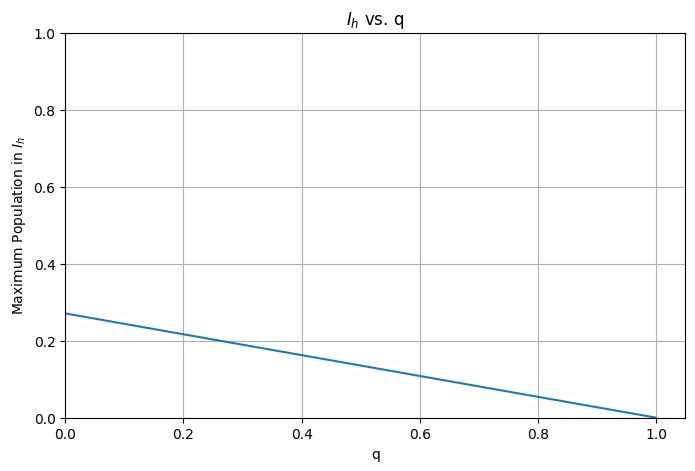

In [ ]:
# Max I_h given q

def get_max_Ih(q_val):
  sol = solve_ivp(sir, t_span, Y0, args=(alpha, lamba, p, rho, q_val, tau_L, tau_H), dense_output=True)
  t = np.linspace(t_initial, t_final, 100)
  y = sol.sol(t)
  return max(y[2])

max_Ih_q = []
q_values = np.arange(0, 1, 0.001)
for q in q_values:
  max_Ih_q.append(get_max_Ih(q))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(q_values, max_Ih_q)
ax.set_ylim(0, 1)
ax.set_xlim(left=-0)
ax.set_xlabel("q")
ax.set_ylabel("Maximum Population in $I_h$")
ax.set_title("$I_h$ vs. q")
plt.grid(True)
plt.show()

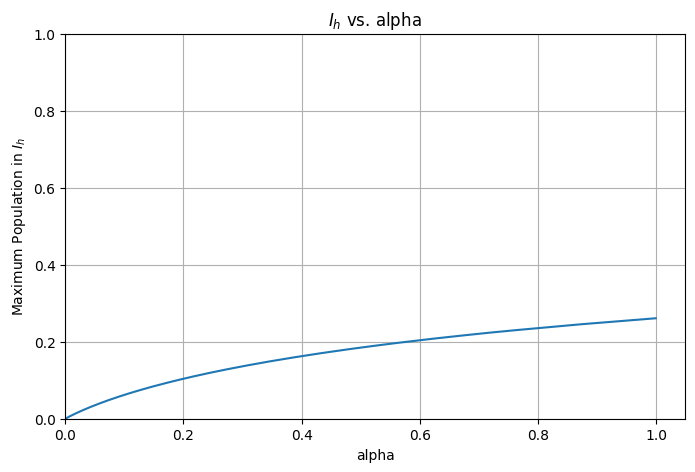

In [ ]:
# Max I_h given alpha

def get_max_Ih(alpha_val):
  sol = solve_ivp(sir, t_span, Y0, args=(alpha_val, lamba, p, rho, q, tau_L, tau_H), dense_output=True)
  t = np.linspace(t_initial, t_final, 100)
  y = sol.sol(t)
  return max(y[2])

max_R_alpha = []
alpha_values = np.arange(0, 1, 0.001)
for a in alpha_values:
  max_R_alpha.append(get_max_Ih(a))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alpha_values, max_R_alpha)
ax.set_ylim(0, 1)
ax.set_xlim(left=-0)
ax.set_xlabel("alpha")
ax.set_ylabel("Maximum Population in $I_h$")
ax.set_title("$I_h$ vs. alpha")
plt.grid(True)
plt.show()

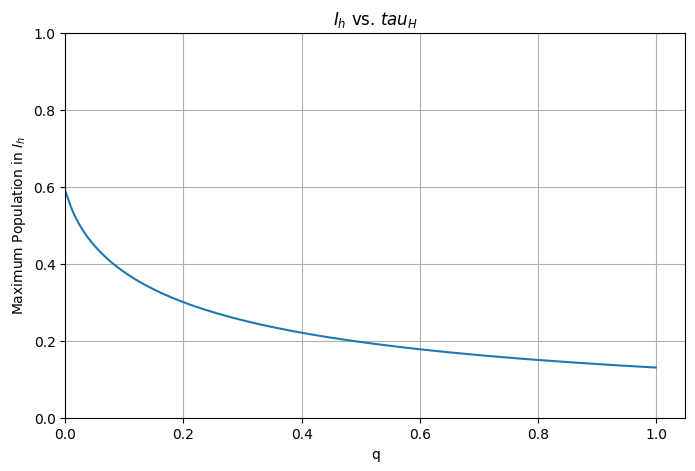

In [ ]:
# Max I_h given tau_H

def get_max_Ih(tau_H_val):
  sol = solve_ivp(sir, t_span, Y0, args=(alpha, lamba, p, rho, q, tau_L, tau_H_val), dense_output=True)
  t = np.linspace(t_initial, t_final, 100)
  y = sol.sol(t)
  return max(y[2])

max_R_tau_H = []
tau_H_values = np.arange(0, 1, 0.001)
for tau in tau_H_values:
  max_R_tau_H.append(get_max_Ih(tau))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tau_H_values, max_R_tau_H)
ax.set_ylim(0, 1)
ax.set_xlim(left=-0)
ax.set_xlabel("q")
ax.set_ylabel("Maximum Population in $I_h$")
ax.set_title("$I_h$ vs. $tau_H$")
plt.grid(True)
plt.show()

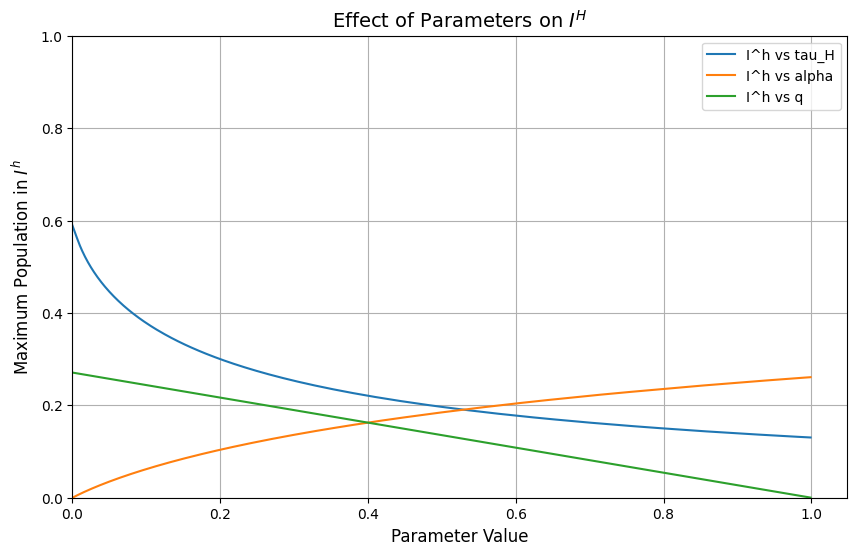

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(tau_H_values, max_R_tau_H, label="I^h vs tau_H")
ax.plot(alpha_values, max_R_alpha, label="I^h vs alpha")
ax.plot(q_values, max_Ih_q, label="I^h vs q")

ax.set_ylim(0, 1)
ax.set_xlim(left=0)
ax.set_xlabel("Parameter Value", fontsize = 12)
ax.set_ylabel("Maximum Population in $I^h$", fontsize = 12)
ax.set_title("Effect of Parameters on $I^H$", fontsize = 14)

plt.grid(True)
plt.legend()
plt.show()

## Maximum $R$ Given Variables

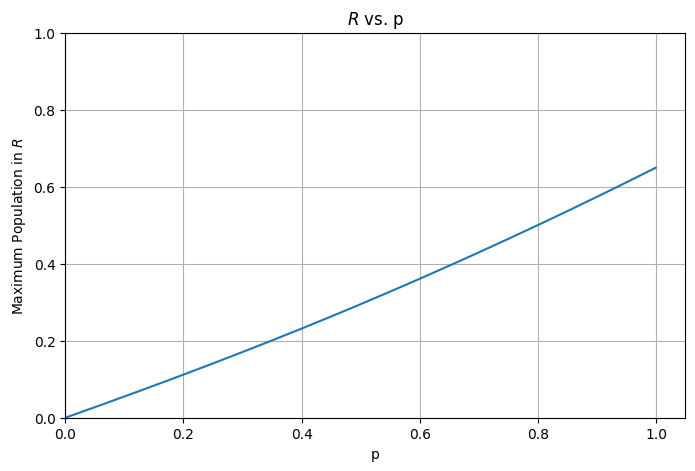

In [ ]:
# Max R given p

def get_max_R(p_val):
  sol = solve_ivp(sir, t_span, Y0, args=(alpha, lamba, p_val, rho, q, tau_L, tau_H), dense_output=True)
  t = np.linspace(t_initial, t_final, 100)
  y = sol.sol(t)
  return max(y[4])

max_R_p = []
p_values = np.arange(0, 1, 0.001)
for p in p_values:
  max_R_p.append(get_max_R(p))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p_values, max_R_p)
ax.set_ylim(0, 1)
ax.set_xlim(left=-0)
ax.set_xlabel("p")
ax.set_ylabel("Maximum Population in $R$")
ax.set_title("$R$ vs. p")
plt.grid(True)
plt.show()

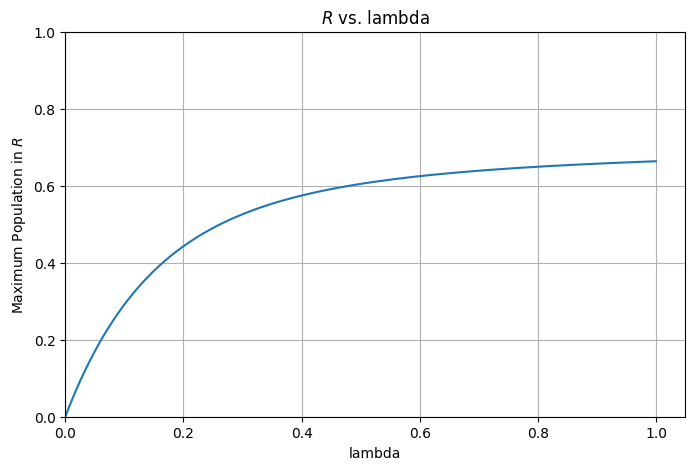

In [ ]:
# Max R given lambda

def get_max_R(lambda_val):
  sol = solve_ivp(sir, t_span, Y0, args=(alpha, lambda_val, p, rho, q, tau_L, tau_H), dense_output=True)
  t = np.linspace(t_initial, t_final, 100)
  y = sol.sol(t)
  return max(y[4])

max_R_lambda = []
lambda_values = np.arange(0, 1, 0.001)
for lamba in lambda_values:
  max_R_lambda.append(get_max_R(lamba))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lambda_values, max_R_lambda)
ax.set_ylim(0, 1)
ax.set_xlim(left=-0)
ax.set_xlabel("lambda")
ax.set_ylabel("Maximum Population in $R$")
ax.set_title("$R$ vs. lambda")
plt.grid(True)
plt.show()

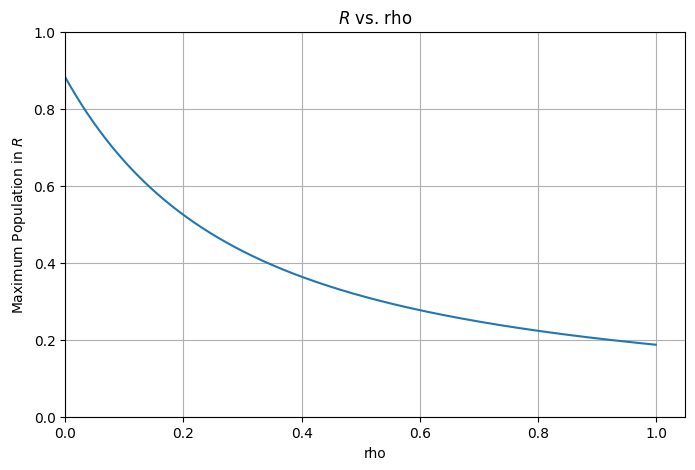

In [ ]:
# Max R given rho

def get_max_R(rho_val):
  sol = solve_ivp(sir, t_span, Y0, args=(alpha, lamba, p, rho_val, q, tau_L, tau_H), dense_output=True)
  t = np.linspace(t_initial, t_final, 100)
  y = sol.sol(t)
  return max(y[4])

max_R_rho = []
rho_values = np.arange(0, 1, 0.001)
for rho in rho_values:
  max_R_rho.append(get_max_R(rho))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rho_values, max_R_rho)
ax.set_ylim(0, 1)
ax.set_xlim(left=-0)
ax.set_xlabel("rho")
ax.set_ylabel("Maximum Population in $R$")
ax.set_title("$R$ vs. rho")
plt.grid(True)
plt.show()

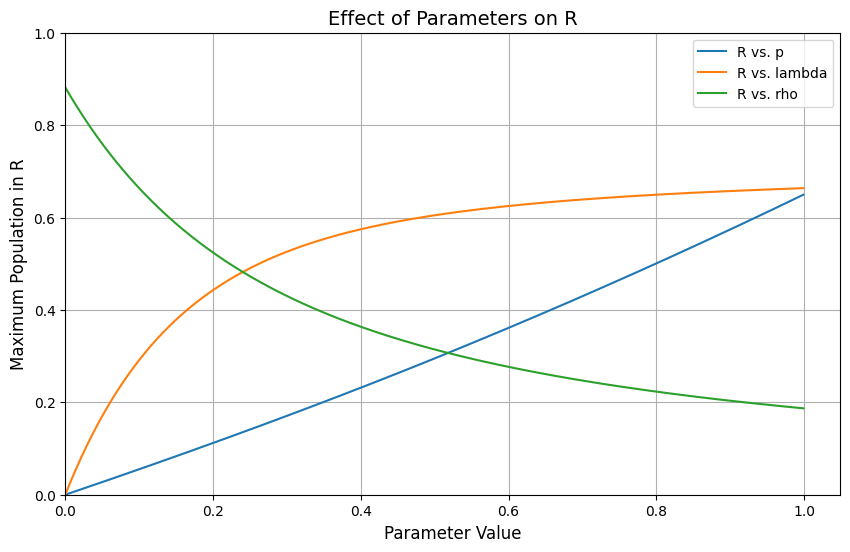

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(p_values, max_R_p, label="R vs. p")
ax.plot(lambda_values, max_R_lambda, label="R vs. lambda")
ax.plot(rho_values, max_R_rho, label="R vs. rho")

ax.set_ylim(0, 1)
ax.set_xlim(left=0)
ax.set_xlabel("Parameter Value", fontsize = 12)
ax.set_ylabel("Maximum Population in R", fontsize = 12)
ax.set_title("Effect of Parameters on R", fontsize = 14)

plt.grid(True)
plt.legend()
plt.show()

# SIIRT-C Model with Two Cohorts (Fusion, Tethering)

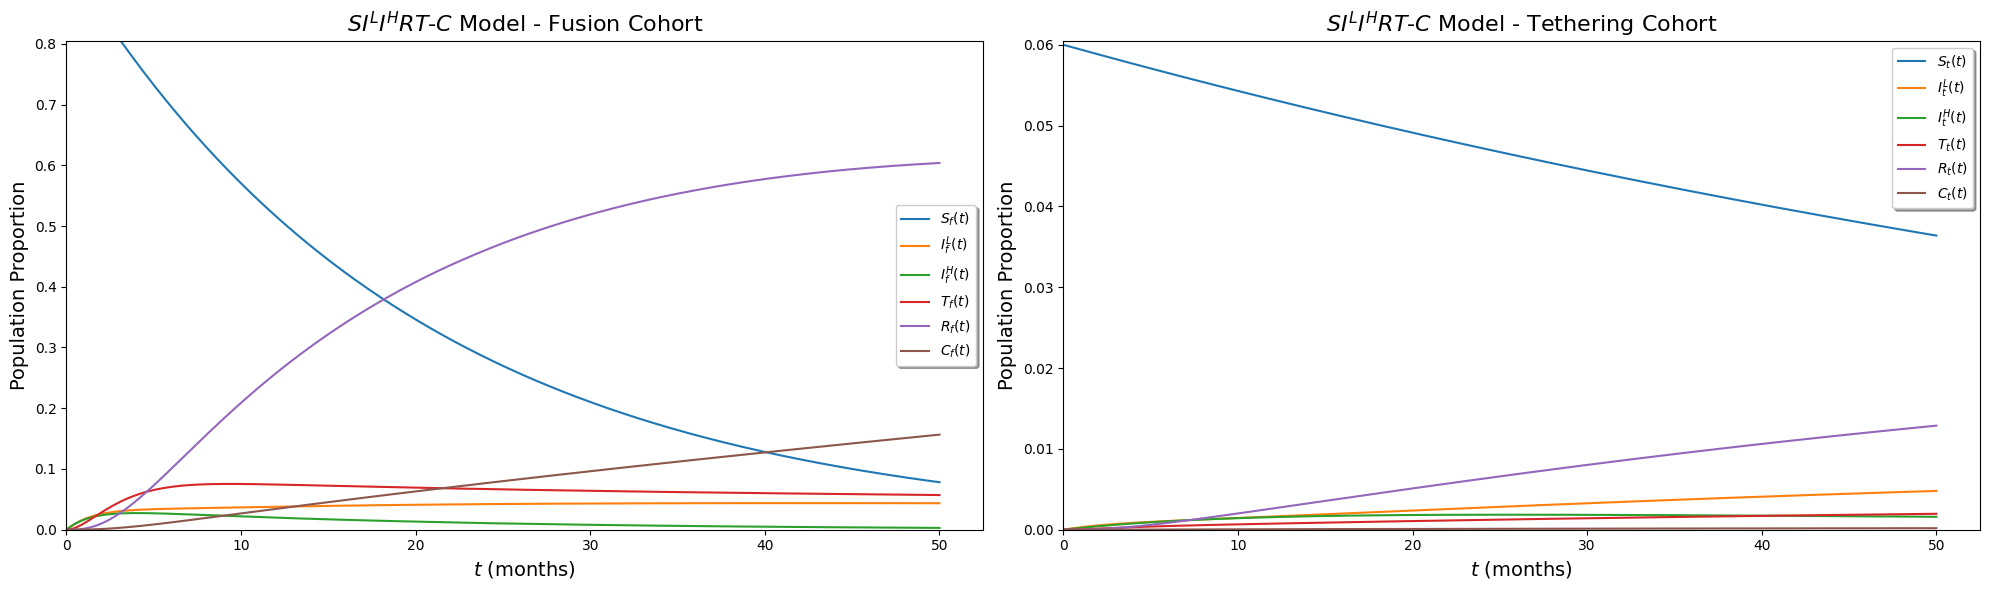

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import array

t_initial, t_final = 0, 50
S0f, S0t, I_L0, I_H0, T0, R0, C0 = 0.94, 0.06, 0, 0, 0.00, 0.00, 0.00

fusion_var = {
  "alpha_f": 0.05,
  "lamba_f": 0.5,
  "p_f": 0.9,
  "rho_f": 0.04,
  "q_f": 0.5,
  "tau_Lf": 0.6,
  "tau_Hf": 0.7
}

tethering_var = {
  "alpha_t": 0.01,
  "lamba_t": 0.8,
  "p_t": 0.95,
  "rho_t": 0.1,
  "q_t": 0.6,
  "tau_Lt": 0.3,
  "tau_Ht": 0.1,
  "beta_t": 0.4
}

Y0_combined = [S0f, I_L0, I_H0, T0, R0, C0, S0t, I_L0, I_H0, T0, R0, C0]
t_span = (t_initial , t_final)


def sir_two_cohorts(t, y, fusion_var, tethering_var):
  S_f, I_Lf, I_Hf, T_f, R_f, C_f = y[:6]
  S_t, I_Lt, I_Ht, T_t, R_t, C_t = y[6:]

  alpha_f = fusion_var["alpha_f"]
  lamba_f = fusion_var["lamba_f"]
  p_f = fusion_var["p_f"]
  rho_f = fusion_var["rho_f"]
  q_f = fusion_var["q_f"]
  tau_Lf = fusion_var["tau_Lf"]
  tau_Hf = fusion_var["tau_Hf"]

  alpha_t = tethering_var["alpha_t"]
  lamba_t = tethering_var["lamba_t"]
  p_t = tethering_var["p_t"]
  rho_t = tethering_var["rho_t"]
  q_t = tethering_var["q_t"]
  tau_Lt = tethering_var["tau_Lt"]
  tau_Ht = tethering_var["tau_Ht"]
  beta_t = tethering_var["beta_t"]


  # Fusion cohort
  dydt_f = [
    -alpha_f * S_f + beta_t * C_t,
    q_f * alpha_f * S_f + rho_f * R_f - tau_Lf * I_Lf,
    (1-q_f) * alpha_f * S_f - tau_Hf * I_Hf,
    tau_Lf * I_Lf + tau_Hf * I_Hf - lamba_f * T_f,
    p_f * lamba_f * T_f - rho_f * R_f,
    (1-p_f) * lamba_f * T_f
  ]

  # Tethering cohort
  dydt_t = [
    -alpha_t * S_t,
    q_t * alpha_t * S_t + rho_t * R_t - tau_Lt * I_Lt,
    (1-q_t) * alpha_t * S_t - tau_Ht * I_Ht,
    tau_Lt * I_Lt + tau_Ht * I_Ht - lamba_t * T_t,
    p_t * lamba_t * T_t - rho_t * R_t,
    (1-p_t) * lamba_t * T_t - beta_t * C_t
  ]

  return dydt_f + dydt_t

sol = solve_ivp(sir_two_cohorts, t_span, Y0_combined, args=(fusion_var, tethering_var), dense_output=True)
t = np.linspace(t_initial, t_final, 500)
y = sol.sol(t)

y_fusion = y[:6]
y_tethering = y[6:]


# Fusion and Tethering side-by-side
fig, (ax_f, ax_t) = plt.subplots(1, 2, figsize=(20, 6))

# Fusion
ax_f.plot(t, y_fusion.T, label=["$S_f(t)$", "$I^L_{f}(t)$", "$I^H_{f}(t)$", "$T_f(t)$", "$R_f(t)$", "$C_f(t)$"])
ax_f.legend(shadow=True)
ax_f.set_xlim(left=-0.01)
ax_f.set_ylim(0,.805)
ax_f.set_xlabel("$t$ (months)", fontsize = 14)
ax_f.set_ylabel("Population Proportion", fontsize = 14)
ax_f.set_title("$SI^LI^HRT$-$C$ Model - Fusion Cohort", fontsize = 16)


# Tethering
ax_t.plot(t, y_tethering.T, label=["$S_t(t)$", "$I^L_{t}(t)$", "$I^H_{t}(t)$", "$T_t(t)$", "$R_t(t)$", "$C_t(t)$"])
ax_t.legend(shadow=True)
ax_t.set_xlim(left=-0.01)
ax_t.set_ylim(0,.0605)
ax_t.set_xlabel("$t$ (months)", fontsize = 14)
ax_t.set_ylabel("Population Proportion", fontsize = 14)
ax_t.set_title("$SI^LI^HRT$-$C$ Model - Tethering Cohort", fontsize = 16)

plt.tight_layout()
plt.show()

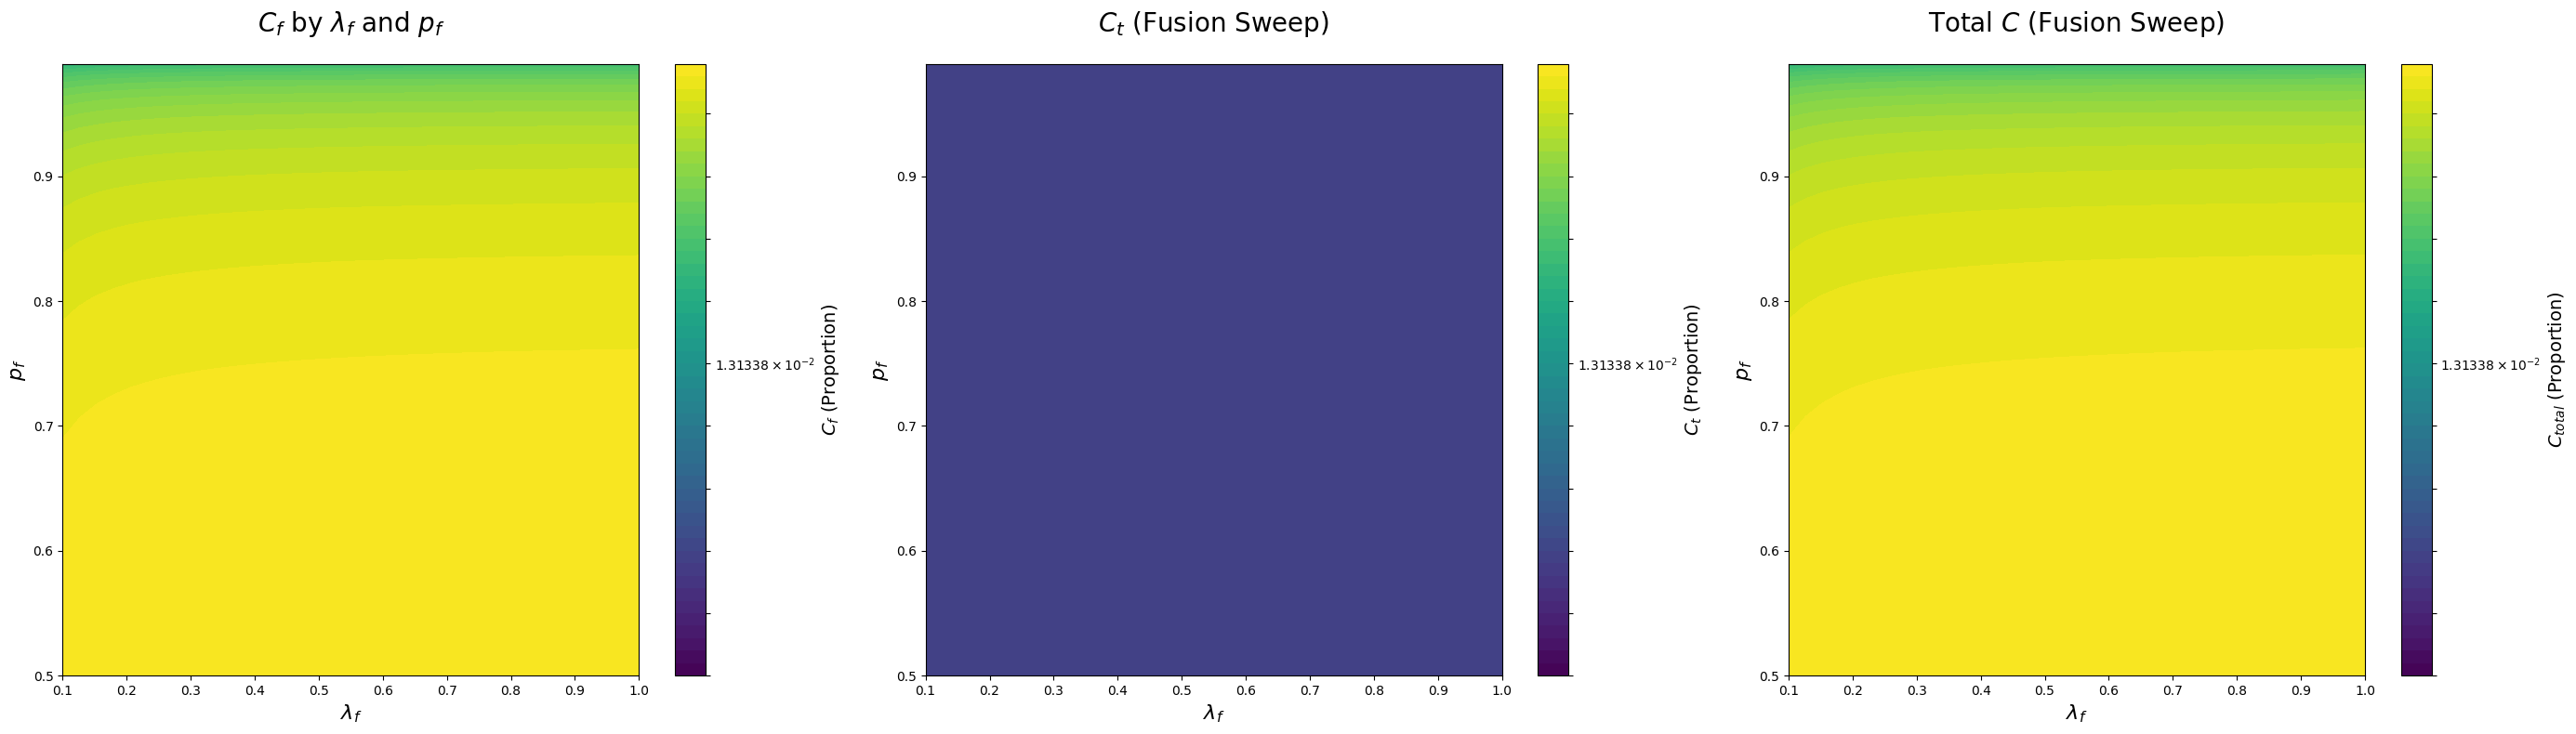

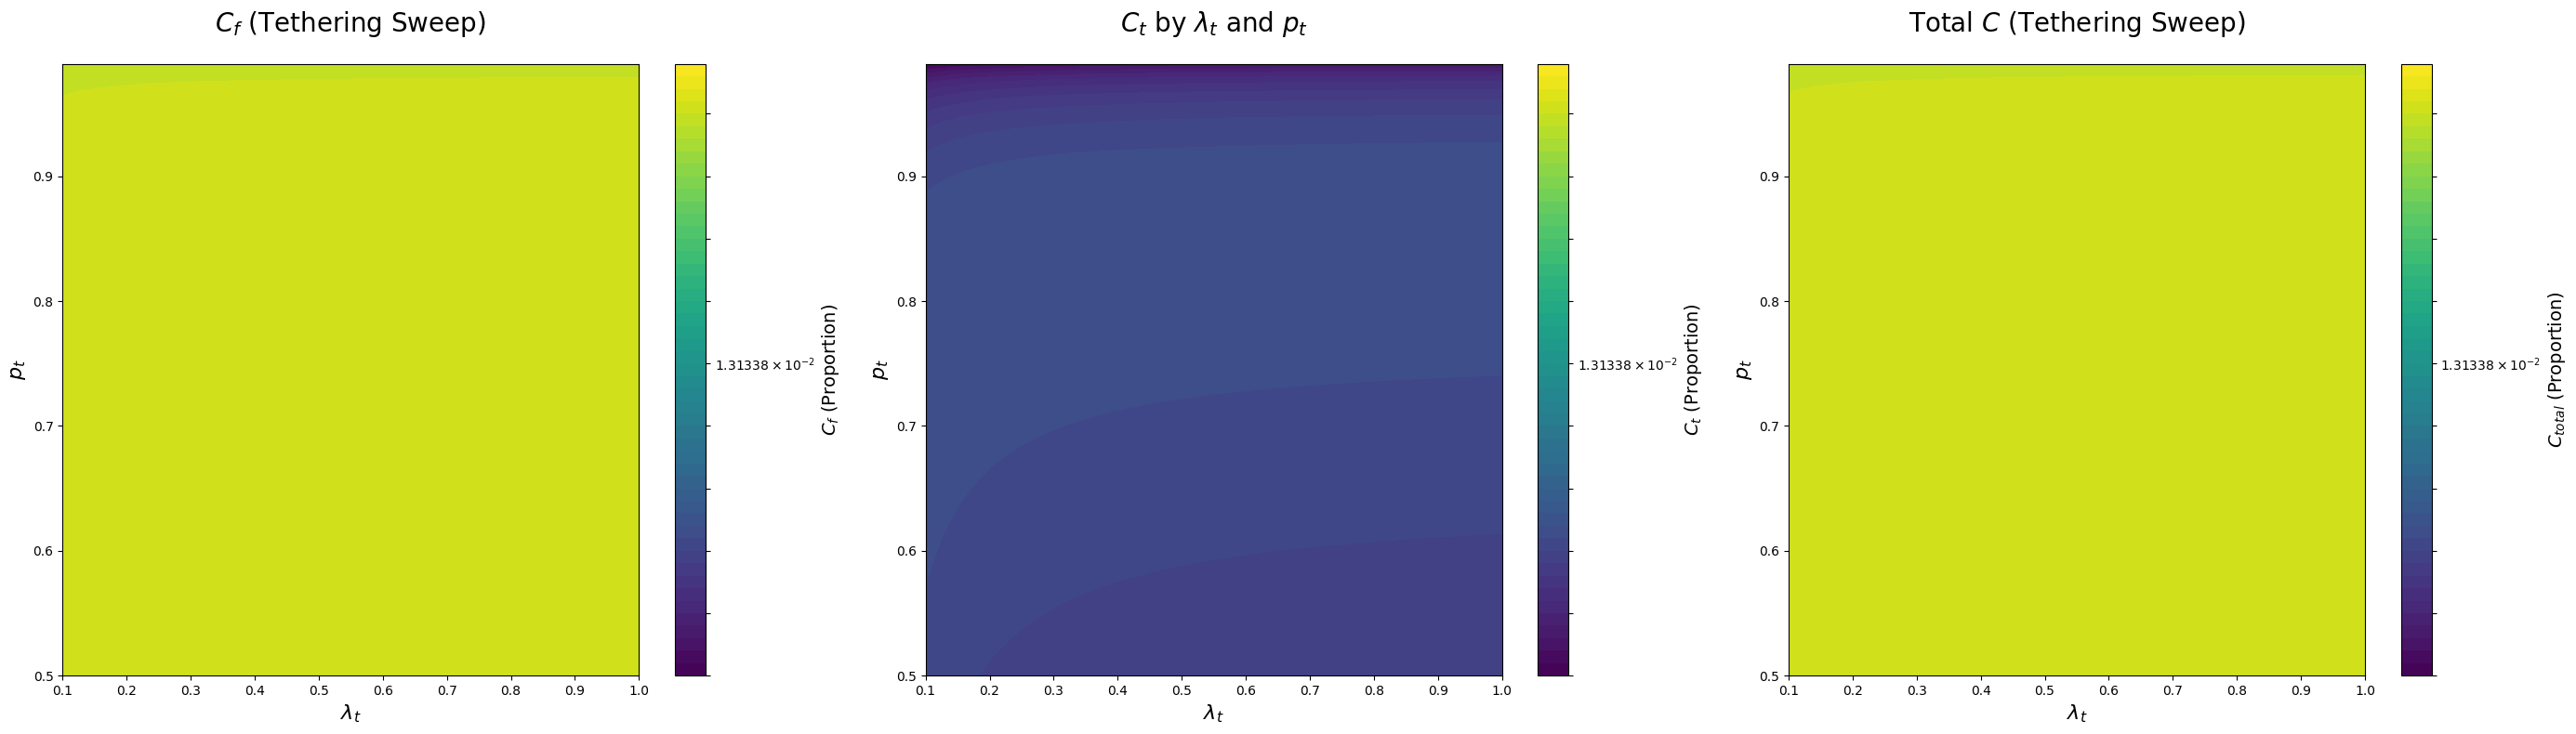

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Base parameters
fusion_base = {
    "alpha_f": 0.05,
    "lamba_f": 0.5,
    "p_f": 0.9,
    "rho_f": 0.04,
    "q_f": 0.5,
    "tau_Lf": 0.6,
    "tau_Hf": 0.7
}

tether_base = {
    "alpha_t": 0.01,
    "lamba_t": 0.8,
    "p_t": 0.95,
    "rho_t": 0.1,
    "q_t": 0.6,
    "tau_Lt": 0.3,
    "tau_Ht": 0.1,
    "beta_t": 0.4
}

Y0 = [0.8, 0, 0, 0, 0, 0, 0.2, 0, 0, 0, 0, 0]
t_span = (0, 50)
t_eval = np.linspace(0, 50, 400)

# Time horizon for long term behavior
t_final = 200
t_span = (0, t_final)
t_eval = np.linspace(0, t_final, 800)

# Helper to run model and return full trajectory
def run_model(fusion_var, tether_var, t_eval=t_eval):
    sol = solve_ivp(sir_two_cohorts, (t_eval[0], t_eval[-1]), Y0,
                    args=(fusion_var, tether_var),
                    t_eval=t_eval, vectorized=False, rtol=1e-6, atol=1e-9)
    return sol.t, sol.y

# Helper to get final chronic proportions
def final_C(fusion_var, tether_var):
    _, y = run_model(fusion_var, tether_var, t_eval=np.linspace(0, t_final, 400))
    C_f_final = y[5, -1]
    C_t_final = y[11, -1]
    return C_f_final, C_t_final

# Sweep settings
n_grid = 35
lamba_range = np.linspace(0.1, 1.0, n_grid)  # transition speed out of T
p_range = np.linspace(0.5, 0.99, n_grid)     # probability of recovery vs chronic

# Preallocate grids
C_f_grid = np.zeros((n_grid, n_grid))
C_t_grid = np.zeros((n_grid, n_grid))
C_total_grid = np.zeros((n_grid, n_grid))

# Fuse tether base copies
for i, lam in enumerate(lamba_range):
    for j, pval in enumerate(p_range):
        # Fusion sweep, tethering kept at base
        fusion_var = fusion_base.copy()
        fusion_var["lamba_f"] = lam
        fusion_var["p_f"] = pval
        tether_var = tether_base.copy()
        C_f_final, C_t_final = final_C(fusion_var, tether_var)
        C_f_grid[j, i] = C_f_final
        C_t_grid[j, i] = C_t_final
        C_total_grid[j, i] = C_f_final + C_t_final

# Sweep tethering cohort's lambda and p while keeping fusion at base
Ctf_grid = np.zeros((n_grid, n_grid))
Ctt_grid = np.zeros((n_grid, n_grid))
Ctotal_tgrid = np.zeros((n_grid, n_grid))

for i, lam in enumerate(lamba_range):
    for j, pval in enumerate(p_range):
        tether_var = tether_base.copy()
        tether_var["lamba_t"] = lam
        tether_var["p_t"] = pval
        fusion_var = fusion_base.copy()
        C_f_final, C_t_final = final_C(fusion_var, tether_var)
        Ctf_grid[j, i] = C_f_final
        Ctt_grid[j, i] = C_t_final
        Ctotal_tgrid[j, i] = C_f_final + C_t_final

FONTSIZE_TITLE = 20
FONTSIZE_LABEL = 16
FONTSIZE_CBAR = 14

# Combine all C grids
all_c_grids = [C_f_grid, C_t_grid, C_total_grid, Ctf_grid, Ctt_grid, Ctotal_tgrid]

# Filter out non-positive values for LogNorm and find the minimum positive value
positive_values = np.array([])
for grid in all_c_grids:
    positive_values = np.concatenate((positive_values, grid[grid > 0]))

if positive_values.size > 0:
    global_min_val = np.min(positive_values)
else:
    global_min_val = 1e-12

global_max_val = np.max([grid.max() for grid in all_c_grids if grid.size > 0]) # Max of all values
global_min_val = max(global_min_val, 1e-12)

num_levels = 50
log_levels = np.logspace(np.log10(global_min_val), np.log10(global_max_val), num_levels)

# Plot contour maps for fusion sweep
L, P = np.meshgrid(lamba_range, p_range)

fig, axes = plt.subplots(1, 3, figsize=(28, 8))

# Plot 1: C_f_grid (fusion sweep)
c1 = axes[0].contourf(L, P, C_f_grid, levels=log_levels, norm=LogNorm(vmin=global_min_val, vmax=global_max_val), cmap='viridis')
axes[0].set_title(r"$C_f$ by $\lambda_f$ and $p_f$", fontsize=FONTSIZE_TITLE, pad=25)
axes[0].set_xlabel(r"$\lambda_f$", fontsize=FONTSIZE_LABEL)
axes[0].set_ylabel(r"$p_f$", fontsize=FONTSIZE_LABEL)
cbar1 = fig.colorbar(c1, ax=axes[0])
cbar1.set_label(r"$C_f$ (Proportion)", fontsize=FONTSIZE_CBAR)

# Plot 2: C_t_grid (fusion sweep)
c2 = axes[1].contourf(L, P, C_t_grid, levels=log_levels, norm=LogNorm(vmin=global_min_val, vmax=global_max_val), cmap='viridis')
axes[1].set_title(r"$C_t$ (Fusion Sweep)", fontsize=FONTSIZE_TITLE, pad=25)
axes[1].set_xlabel(r"$\lambda_f$", fontsize=FONTSIZE_LABEL)
axes[1].set_ylabel(r"$p_f$", fontsize=FONTSIZE_LABEL)
cbar2 = fig.colorbar(c2, ax=axes[1])
cbar2.set_label(r"$C_t$ (Proportion)", fontsize=FONTSIZE_CBAR)

# Plot 3: C_total_grid (fusion sweep)
c3 = axes[2].contourf(L, P, C_total_grid, levels=log_levels, norm=LogNorm(vmin=global_min_val, vmax=global_max_val), cmap='viridis')
axes[2].set_title(r"Total $C$ (Fusion Sweep)", fontsize=FONTSIZE_TITLE, pad=25)
axes[2].set_xlabel(r"$\lambda_f$", fontsize=FONTSIZE_LABEL)
axes[2].set_ylabel(r"$p_f$", fontsize=FONTSIZE_LABEL)
cbar3 = fig.colorbar(c3, ax=axes[2])
cbar3.set_label(r"$C_{total}$ (Proportion)", fontsize=FONTSIZE_CBAR)

plt.tight_layout()
plt.show()

# Plot contour maps for tethering sweep
fig, axes = plt.subplots(1, 3, figsize=(28, 8))

# Plot 4: C_f_grid (tethering sweep)
c4 = axes[0].contourf(L, P, Ctf_grid, levels=log_levels, norm=LogNorm(vmin=global_min_val, vmax=global_max_val), cmap='viridis')
axes[0].set_title(r"$C_f$ (Tethering Sweep)", fontsize=FONTSIZE_TITLE, pad=25)
axes[0].set_xlabel(r"$\lambda_t$", fontsize=FONTSIZE_LABEL)
axes[0].set_ylabel(r"$p_t$", fontsize=FONTSIZE_LABEL)
cbar4 = fig.colorbar(c4, ax=axes[0])
cbar4.set_label(r"$C_f$ (Proportion)", fontsize=FONTSIZE_CBAR)

# Plot 5: C_t_grid (tethering sweep)
c5 = axes[1].contourf(L, P, Ctt_grid, levels=log_levels, norm=LogNorm(vmin=global_min_val, vmax=global_max_val), cmap='viridis')
axes[1].set_title(r"$C_t$ by $\lambda_t$ and $p_t$", fontsize=FONTSIZE_TITLE, pad=25)
axes[1].set_xlabel(r"$\lambda_t$", fontsize=FONTSIZE_LABEL)
axes[1].set_ylabel(r"$p_t$", fontsize=FONTSIZE_LABEL)
cbar5 = fig.colorbar(c5, ax=axes[1])
cbar5.set_label(r"$C_t$ (Proportion)", fontsize=FONTSIZE_CBAR)

# Plot 6: C_total_grid (tethering sweep)
c6 = axes[2].contourf(L, P, Ctotal_tgrid, levels=log_levels, norm=LogNorm(vmin=global_min_val, vmax=global_max_val), cmap='viridis')
axes[2].set_title(r"Total $C$ (Tethering Sweep)", fontsize=FONTSIZE_TITLE, pad=25)
axes[2].set_xlabel(r"$\lambda_t$", fontsize=FONTSIZE_LABEL)
axes[2].set_ylabel(r"$p_t$", fontsize=FONTSIZE_LABEL)
cbar6 = fig.colorbar(c6, ax=axes[2])
cbar6.set_label(r"$C_{total}$ (Proportion)", fontsize=FONTSIZE_CBAR)

plt.tight_layout()
plt.show()